<a href="https://colab.research.google.com/github/Ankitha1089/Marketing-Campaign-Analysis/blob/main/MarketingEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/cleaned_marketing_data.csv')


In [ ]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 80)]

In [ ]:
upper_income = df['Income'].quantile(0.99)
df['Income'] = np.where(df['Income'] > upper_income, upper_income, df['Income'])


In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Response,Complain,Country,Age,Children,Total_Spend,Total_Purchases,Customer_Tenure_Days,Marital_Status_Clean,campaign_cols
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,0,0,Spain,41,1,69,13,4816,Married,0
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,0,0,Spain,51,2,39,4,4672,Single,0
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,0,0,Australia,48,0,1512,12,4396,Married,0
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,0,0,Spain,50,1,478,16,4238,Married,0
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,0,0,Canada,45,2,330,9,4267,Single,0


UNIVARIATE ANALYSIS

In [ ]:
bins = [0, 30, 40, 50, 60, 70, 80]
labels = ["=30",  "31–40", "41–50", "51–60", "61-70", "71-81"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True)

df["Age_Group"].value_counts().sort_index()


,count
Age_Group,
=30,1031
31–40,5983
41–50,16076
51–60,15971
61-70,10534
71-81,5389


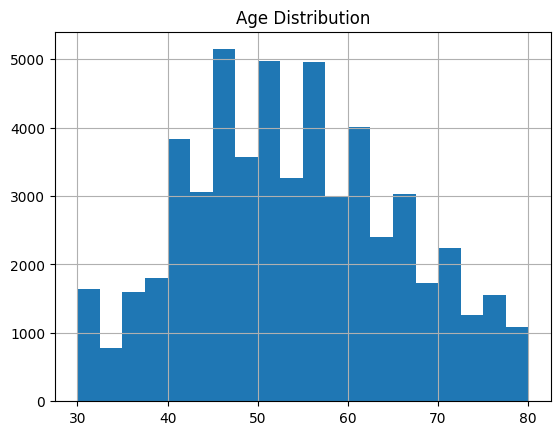

In [ ]:
#Age Distribution
df['Age'].hist(bins=20)
plt.title("Age Distribution")
plt.show()


In [ ]:
bins = [0, 20000, 40000, 60000, 80000, 120000]
labels = ["<=20000",  "21000–40000", "41000–60000", "61–80000", "81000-120000"]

df["Income_range"] = pd.cut(df["Income"], bins=bins, labels=labels, right=True)

df["Income_range"].value_counts().sort_index()

,count
Income_range,
<=20000,10536
21000–40000,8236
41000–60000,9363
61–80000,9861
81000-120000,16988


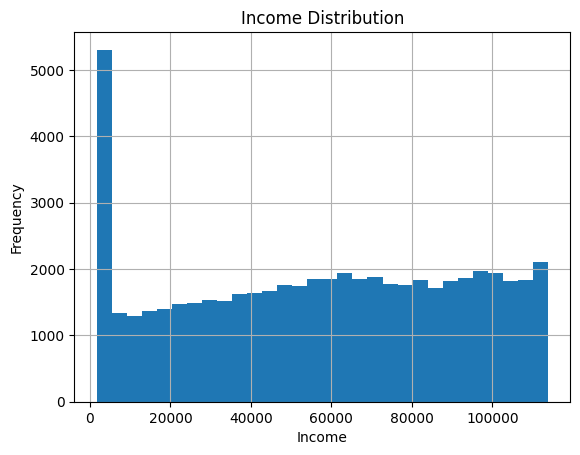

In [ ]:
#Income Distribution
df['Income'].hist(bins=30)
plt.title("Income Distribution")
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()


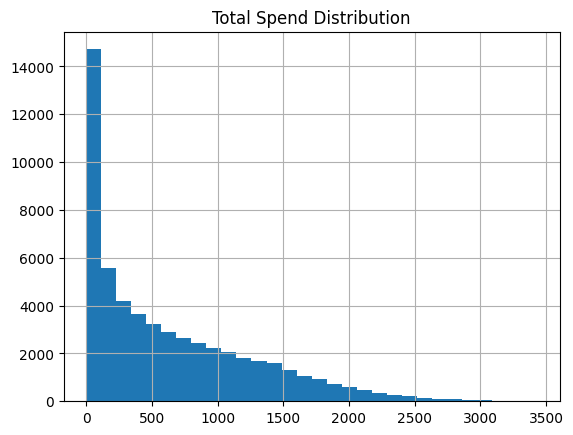

In [ ]:
#Total Spend Distribution

# x--> no. of customers
# y--> range of spending

df['Total_Spend'].hist(bins=30)
plt.title("Total Spend Distribution")
plt.show()


In [ ]:
# Campaign Response Rate

df['Response'].value_counts(normalize=True)


,proportion
Response,
0,0.853266
1,0.146734


BIVARIATE ANALYSIS


In [ ]:
df.groupby('Response')['Income'].mean()


,Income
Response,
0,54003.608347
1,75246.063510


In [ ]:
df['Income_Group'] = pd.qcut(
    df['Income'],
    q=4,
    labels=['Low Income', 'Mid Income', 'High Income', 'Very High Income']
)


In [ ]:
income_response_rate = (
    df.groupby('Income_Group')['Response']
    .mean()
    .reset_index()
)

income_response_rate['Response_Rate_%'] = income_response_rate['Response'] * 100

income_response_rate


/tmp/ipython-input-1867632840.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Income_Group')['Response']


,Income_Group,Response,Response_Rate_%
0,Low Income,0.048814,4.881420
1,Mid Income,0.112906,11.290557
2,High Income,0.175324,17.532373
3,Very High Income,0.249891,24.989088


In [ ]:
df.groupby('Response')['Total_Spend'].mean()


,Total_Spend
Response,
0,584.704152
1,934.572633


In [ ]:
df.groupby('Response')['Age'].mean()


,Age
Response,
0,53.519332
1,55.482647


In [ ]:
campaign_cols = [
    'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5'
]

age_campaign = (
    df.groupby('Age_Group')[campaign_cols]
    .sum()
    .reset_index()
)

age_campaign


/tmp/ipython-input-3465434817.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')[campaign_cols]


,Age_Group,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
0,18–30,0,0,0,0,0
1,31–45,1372,129,734,613,412
2,46–60,3172,354,1542,1362,1100
3,61–80,2772,299,1134,1122,970


In [ ]:
bins = [18, 30, 45, 60, 80]
labels = ['18–30', '31–45', '46–60', '61–81']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)


In [ ]:
responded = (
    df[df['Response'] == 1]
    .groupby('Age_Group')
    .size()
    .reset_index(name='Responded')
)


/tmp/ipython-input-1453259948.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Age_Group')


In [ ]:
total = (
    df.groupby('Age_Group')
    .size()
    .reset_index(name='Total')
)


/tmp/ipython-input-68458297.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')


In [ ]:
age_response = responded.merge(total, on='Age_Group')
age_response['Response_Rate_%'] = (
    age_response['Responded'] / age_response['Total'] * 100
)

age_response.sort_values('Response_Rate_%', ascending=False)


,Age_Group,Responded,Total,Response_Rate_%
3,61–80,2984,17026,17.526136
2,46–60,3476,24929,13.943600
1,31–45,1549,12719,12.178630
0,18–30,0,0,NaN


In [ ]:
df.groupby('Response')['Children'].mean()


,Children
Response,
0,0.940596
1,0.691869


PRODUCT-LEVEL ANALYSIS

In [ ]:
spend_cols = [
    'MntWines', 'MntMeatProducts', 'MntFishProducts',
    'MntFruits', 'MntSweetProducts', 'MntGoldProds'
]


In [ ]:
df[spend_cols].mean().sort_values(ascending=False)


,0
MntMeatProducts,266.794940
MntWines,245.076349
MntFishProducts,50.766659
MntGoldProds,35.231413
MntSweetProducts,22.201222
MntFruits,15.971028


In [ ]:
df.groupby('Response')[spend_cols].mean()


,MntWines,MntMeatProducts,MntFishProducts,MntFruits,MntSweetProducts,MntGoldProds
Response,,,,,,
0,222.155299,249.629039,46.31275,14.189893,19.936887,32.480284
1,378.363907,366.615890,76.66646,26.328458,35.368493,51.229425


CHANNEL ANALYSIS


In [ ]:
purchase_cols = [
    'NumWebPurchases',
    'NumStorePurchases',
    'NumCatalogPurchases',
    'NumDealsPurchases'
]


In [ ]:
df[purchase_cols + ['NumWebVisitsMonth']].mean()


,0
NumWebPurchases,4.242434
NumStorePurchases,4.699294
NumCatalogPurchases,2.104721
NumDealsPurchases,2.172432
NumWebVisitsMonth,5.176979


In [ ]:
df.groupby('Response')[purchase_cols + ['NumWebVisitsMonth']].mean()


,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumDealsPurchases,NumWebVisitsMonth
Response,,,,,
0,4.107980,4.546594,1.978003,2.184841,5.279542
1,5.024294,5.587258,2.841596,2.100273,4.580565


CATEGORICAL vs RESPONSE

In [ ]:
#Education vs Response
df.groupby('Education')['Response'].mean().sort_values(ascending=False)


,Response
Education,
Graduation,0.172194
Master,0.143161
Phd,0.137597
2N Cycle,0.114305
Basic,0.091772


In [ ]:
#Marital Status vs Response
df.groupby('Marital_Status_Clean')['Response'].mean().sort_values(ascending=False)


,Response
Marital_Status_Clean,
Other,0.197658
Single,0.170004
Married,0.127236


In [ ]:
#Country vs Response
df.groupby('Country')['Response'].mean().sort_values(ascending=False)


,Response
Country,
Australia,0.201584
India,0.186455
Germany,0.166360
Usa,0.154923
Mexico,0.149770
Saudi Arabia,0.148585
Spain,0.128877
Canada,0.114753


In [ ]:
df.tail(100)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Age,Children,Total_Spend,Total_Purchases,Customer_Tenure_Days,Marital_Status_Clean,campaign_cols,Age_Group,Income_range,Income_Group
55884,3621093,1984,Graduation,Widow,1730.0,1,1,2012-08-21,56,0,...,42,2,0,6,4904,Single,0,31–45,<=20000,Low Income
55885,15589711,1966,Graduation,Widow,46061.5,1,0,2013-11-10,13,0,...,60,1,34,8,4458,Single,1,61–80,41000–60000,Mid Income
55886,7091829,1980,Phd,Divorced,35542.0,1,1,2013-03-13,90,0,...,46,2,176,11,4700,Single,0,46–60,21000–40000,Mid Income
55887,12802715,1984,Master,Together,79796.9,0,0,2012-11-29,87,183,...,42,0,412,16,4804,Married,0,31–45,61–80000,High Income
55888,681579,1967,Master,Married,60329.3,0,1,2013-04-15,52,643,...,59,1,909,6,4667,Married,0,46–60,61–80000,High Income
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55981,2485439,1985,Graduation,Married,32533.4,0,0,2013-04-05,99,8,...,41,0,53,19,4677,Married,0,31–45,21000–40000,Mid Income
55982,9202496,1992,Basic,Single,70496.3,0,1,2013-01-31,9,835,...,34,1,924,12,4741,Single,0,31–45,61–80000,High Income
55983,14677746,1950,Graduation,Together,21072.0,1,0,2013-06-25,24,0,...,76,1,608,5,4596,Married,1,61–80,21000–40000,Low Income
55984,3843719,1976,Graduation,Together,64218.1,0,0,2014-05-12,81,8,...,50,0,69,8,4275,Married,0,46–60,61–80000,High Income


In [ ]:
df['Income'].max()

113794.42999999998

In [ ]:
import pandas as pd

# Example: select rows where Age is 80
result = df[df['Income_range'] == 113794 ]

# Display the result
print(result)


Empty DataFrame
Columns: [ID, Year_Birth, Education, Marital_Status, Income, Kidhome, Teenhome, Dt_Customer, Recency, MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds, NumDealsPurchases, NumWebPurchases, NumCatalogPurchases, NumStorePurchases, NumWebVisitsMonth, AcceptedCmp3, AcceptedCmp4, AcceptedCmp5, AcceptedCmp1, AcceptedCmp2, Response, Complain, Country, Age, Children, Total_Spend, Total_Purchases, Customer_Tenure_Days, Marital_Status_Clean, campaign_cols, Age_Group, Income_range, Income_Group]
Index: []

[0 rows x 38 columns]


In [ ]:
print(df[df['Income_range'].isnull()].index)


Index([    6,    11,    15,    17,    20,    22,    27,    31,    34,    68,
       ...
       55907, 55912, 55914, 55925, 55928, 55942, 55952, 55956, 55957, 55980],
      dtype='int64', length=7138)


In [ ]:
df.head(7)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Age,Children,Total_Spend,Total_Purchases,Customer_Tenure_Days,Marital_Status_Clean,campaign_cols,Age_Group,Income_range,Income_Group
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,41,1,69,13,4816,Married,0,41–50,41000–60000,High Income
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,51,2,39,4,4672,Single,0,51–60,<=20000,Low Income
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,48,0,1512,12,4396,Married,0,41–50,81000-120000,Very High Income
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,50,1,478,16,4238,Married,0,41–50,61–80000,High Income
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,45,2,330,9,4267,Single,0,41–50,41000–60000,Mid Income
5,7194200,1977,2N Cycle,Married,36353.5,1,0,2014-03-28,99,0,...,49,1,132,12,4320,Married,0,41–50,21000–40000,Mid Income
6,2330269,1960,Basic,Divorced,111080.3,0,0,2013-08-05,14,152,...,66,0,843,14,4555,Single,0,61-70,NaN,Very High Income


In [ ]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df.to_csv("marketing_data_eda_ready.csv", index=False)


In [ ]:
import pandas as pd
df = pd.read_csv('/content/marketing_data_eda_ready.csv')

In [ ]:
df['Income_Band'] = pd.qcut(df['Income'], 4, labels=['Low','Mid','High','Very High'])


In [ ]:
df['Age_Band'] = pd.cut(
    df['Age'],
    bins=[18,30,45,60,80],
    labels=['18-29','30-44','45-59','60+']
)


In [ ]:
pd.pivot_table(
    df,
    values='Response',
    index='Income_Band',
    columns='Age_Band',
    aggfunc='mean'
)


/tmp/ipython-input-257939460.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


Age_Band,18-29,30-44,45-59,60+
Income_Band,,,,
Low,0.043605,0.040389,0.049613,0.058986
Mid,0.100000,0.094865,0.115066,0.127208
High,0.132159,0.169589,0.167361,0.192562
Very High,0.194737,0.224640,0.248682,0.267690


In [ ]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
high_spend_threshold = df['Total_Spend'].quantile(0.90)
high_spend_threshold


np.float64(1556.0)

In [ ]:
(df['Total_Spend'] > high_spend_threshold).sum()


np.int64(5490)

In [ ]:
df['High_Spender'] = df['Total_Spend'] > high_spend_threshold


In [ ]:
df.groupby('High_Spender')['Response'].mean()


,Response
High_Spender,
False,0.134279
True,0.259016


In [ ]:
df.to_csv("marketing_data_eda_ready.csv", index=False)
